# Spam Classification
Developed an SMS Spam Classification model using NLP and Machine Learning. Text messages were cleaned, lemmatized, and converted into TF-IDF features before training Multinomial Naive Bayes and LinearSVC models. LinearSVC achieved the best performance and was selected as the final model for spam detection. The trained model and vectorizer were saved for future inference.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


## 2. Load data

In [2]:
data = pd.read_csv("spam.csv", encoding="latin-1")
df = data.copy()
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


## 3. Clean columns

In [4]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace=True)


In [5]:
df.rename(columns={"v1":"target","v2":"text"}, inplace=True)


In [6]:
df.isna().sum()


target    0
text      0
dtype: int64

In [7]:
df.duplicated().sum()


np.int64(403)

In [8]:
df.drop_duplicates(inplace=True)


## 4. Target distribution

In [9]:
counts = df["target"].value_counts()
print(counts)
print(f"Spam rate: {counts['spam'] / counts.sum() * 100:.2f}%")


target
ham     4516
spam     653
Name: count, dtype: int64
Spam rate: 12.63%


**Visual 1 — class balance.**

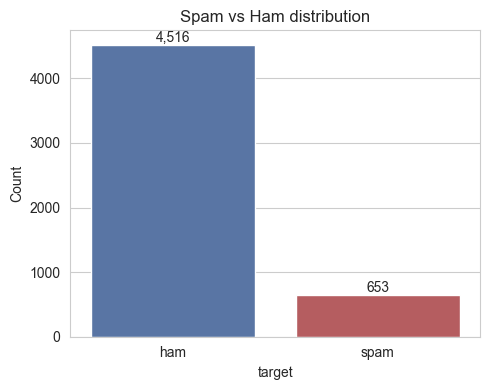

In [10]:
plt.figure(figsize=(5,4))
ax = sns.barplot(x=counts.index, y=counts.values, palette=["#4C72B0","#C44E52"])
for i,v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.title("Spam vs Ham distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 5. Text cleaning

In [11]:
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [12]:
stop_words = stopwords.words("english")
lemmatizer = WordNetLemmatizer()


In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.strip()
    text = text.split()
    text = [word for word in text if word not in stop_words]
    text = [lemmatizer.lemmatize(word) for word in text]
    return " ".join(text)


In [14]:
df["text_clean"] = df["text"].apply(clean_text)
df.head()


,target,text,text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


**Visual 2 — WordCloud for checking word importance.**

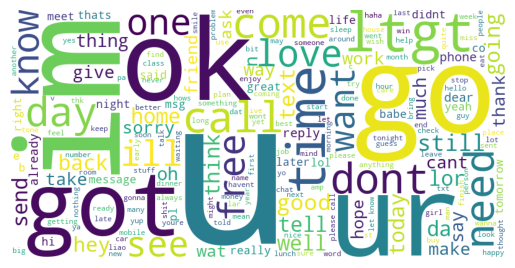

In [15]:
from wordcloud import WordCloud
text = " ".join(df["text_clean"])

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

**Visual 3 — message length by class.** *italicized text*

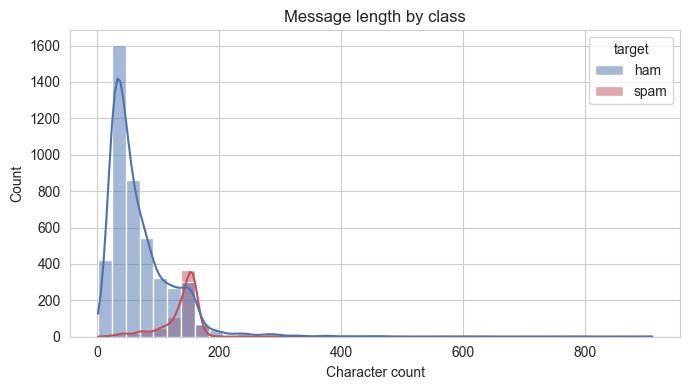

In [16]:
df["msg_len"] = df["text"].apply(len)

plt.figure(figsize=(7,4))
sns.histplot(data=df, x="msg_len", hue="target", bins=40, kde=True, palette=["#4C72B0","#C44E52"])
plt.title("Message length by class")
plt.xlabel("Character count")
plt.tight_layout()
plt.show()


**Visual 4 — most frequent words per class.**

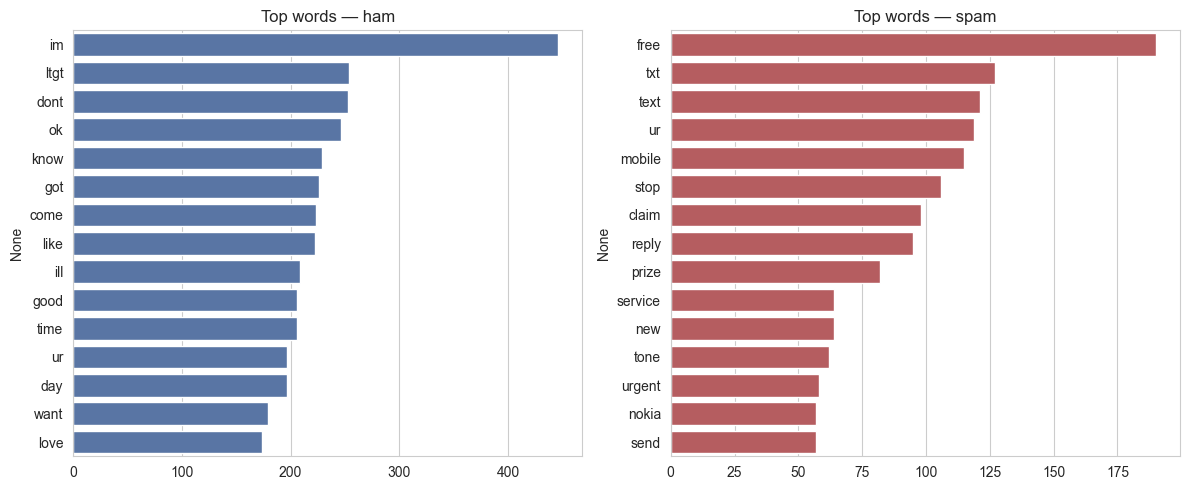

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

def top_words(texts, n=15):
    cv = CountVectorizer(stop_words="english")
    bow = cv.fit_transform(texts)
    freqs = np.asarray(bow.sum(axis=0)).flatten()
    words = cv.get_feature_names_out()
    return pd.Series(freqs, index=words).sort_values(ascending=False).head(n)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

top_ham = top_words(df.loc[df["target"]=="ham","text_clean"])
top_spam = top_words(df.loc[df["target"]=="spam","text_clean"])

sns.barplot(x=top_ham.values, y=top_ham.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Top words — ham")

sns.barplot(x=top_spam.values, y=top_spam.index, ax=axes[1], color="#C44E52")
axes[1].set_title("Top words — spam")

plt.tight_layout()
plt.show()


## 6. Train/test split + TF-IDF

In [18]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score


In [19]:
X = df["text_clean"]
y = df["target"]

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [20]:
tfidf = TfidfVectorizer(ngram_range=(1,2))
train_X = tfidf.fit_transform(train_X)
test_X = tfidf.transform(test_X)


## 7. Models

### Linear SVC

In [21]:
svm = LinearSVC(class_weight="balanced", random_state=42)
svm.fit(train_X, train_y)
pred_svm = svm.predict(test_X)
print("Classification Report:\n", classification_report(test_y, pred_svm))


Classification Report:
               precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.94      0.92      0.93       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



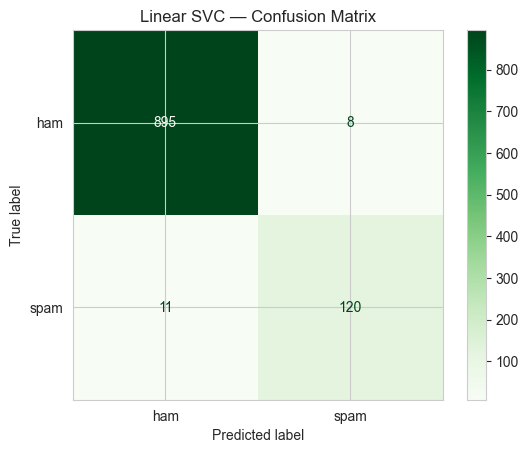

In [22]:
ConfusionMatrixDisplay.from_predictions(test_y, pred_svm, cmap="Greens")
plt.title("Linear SVC — Confusion Matrix")
plt.show()


### Multinomial Naive Bayes

In [23]:
nb = MultinomialNB()
nb.fit(train_X, train_y)
pred_nb = nb.predict(test_X)
print("Classification Report:\n", classification_report(test_y, pred_nb))


Classification Report:
               precision    recall  f1-score   support

         ham       0.95      1.00      0.97       903
        spam       1.00      0.62      0.76       131

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.95      0.95      0.95      1034



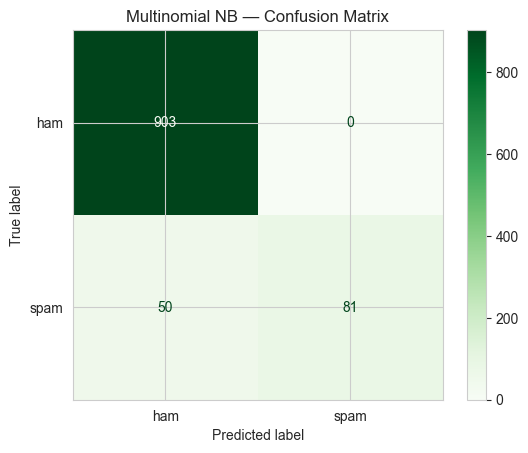

In [24]:
ConfusionMatrixDisplay.from_predictions(test_y, pred_nb, cmap="Greens")
plt.title("Multinomial NB — Confusion Matrix")
plt.show()


## 8. Model comparison

In [25]:
def get_metrics(y_true, y_pred, label="Model"):
    return {
        "Model": label,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label="spam"),
        "Recall": recall_score(y_true, y_pred, pos_label="spam"),
        "F1 Score": f1_score(y_true, y_pred, pos_label="spam"),
    }

comparison = pd.DataFrame([
    get_metrics(test_y, pred_nb, "Multinomial NB"),
    get_metrics(test_y, pred_svm, "Linear SVC"),
]).set_index("Model")

comparison


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Multinomial NB,0.951644,1.0000,0.618321,0.764151
Linear SVC,0.981625,0.9375,0.916031,0.926641


**Visual 5 — model comparison chart.**

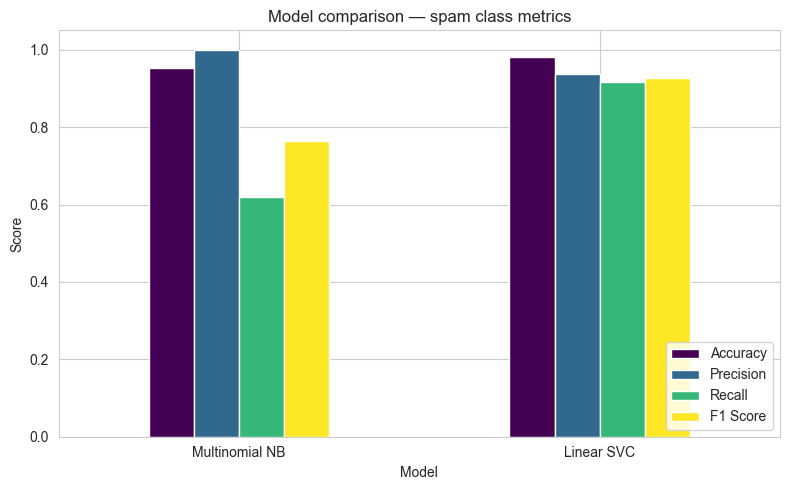

In [26]:
comparison.plot(kind="bar", figsize=(8,5), colormap="viridis")
plt.title("Model comparison — spam class metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


Linear SVC is the stronger model overall (higher recall on spam without sacrificing much precision)

## 9. Saving model

In [27]:
import joblib

joblib.dump(svm, "Spam_classification.pkl")
joblib.dump(tfidf, "tfidf_vect.pkl")


['tfidf_vect.pkl']

## 10. Quick sanity checks

In [28]:
message = ["Congratulations! You have won a free iPhone. Click here now."]
message = [clean_text(msg) for msg in message]
message = tfidf.transform(message)
print(svm.predict(message))


['spam']


In [29]:
message = ["Hey, I'll be there in 10 minutes."]
message = [clean_text(msg) for msg in message]
message = tfidf.transform(message)
print(svm.predict(message))


['ham']
